In [44]:
import numpy as np
import skrf as rf

# Load your data
G_vals = np.load("data_output/nyquist/G_vals.npy")  # shape: (N,)
omega_range = np.load("data_output/nyquist/omega_range.npy")  # shape: (N,)

# Convert omega to frequency in Hz (if omega is in rad/s)
freq_Hz = omega_range / (2 * np.pi)

# Create a frequency object
f = rf.Frequency.from_f(freq_Hz, unit='Hz')

# Reshape G_vals to (N, 1, 1) for a 1-port network
s_params = G_vals.reshape(-1, 1, 1)

# Create the Network object
ntw = rf.Network(frequency=f, s=s_params, name='G_fit')

# Now use VectorFitting
from skrf.vectorFitting import VectorFitting

vf = VectorFitting(ntw)
vf.vector_fit(n_poles_real=2, n_poles_cmplx=2)  # Adjust pole numbers as needed

# Access fitted model
poles = vf.poles
residues = vf.residues

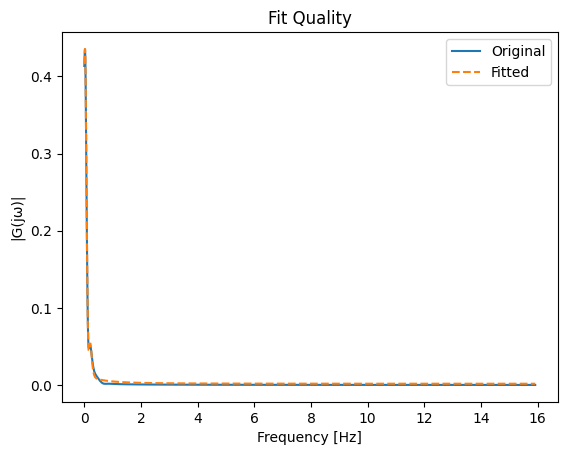

In [45]:
# i, j = 0, 0 for SISO (port 1 to port 1)
G_fit = vf.get_model_response(0, 0, freq_Hz)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(freq_Hz, np.abs(G_vals), label='Original')
plt.plot(freq_Hz, np.abs(G_fit), '--', label='Fitted')
plt.xlabel('Frequency [Hz]')
plt.ylabel('|G(jω)|')
plt.legend()
plt.title('Fit Quality')
plt.show()

In [46]:
import control
from scipy.signal import invres
c = np.real(vf.constant_coeff[0])  # constant term (scalar)
d = np.real(vf.proportional_coeff[0])  # proportional term (scalar)
# Example: build transfer function from residues and poles
# Start with s*d + c
# Get residues and poles as arrays
residues = np.array(residues).flatten()
poles = np.array(poles).flatten()

num, den = invres(residues, poles, [d, c])

# Force to real if imaginary part is negligible
num = np.real_if_close(num, tol=1000)
den = np.real_if_close(den, tol=1000)

# If still complex (rare), take real part explicitly
num = np.real(num)
den = np.real(den)

# Remove leading zeros (if any)
num = np.trim_zeros(num, 'f')
den = np.trim_zeros(den, 'f')

# Now create the transfer function
G = control.TransferFunction(num, den)
print(G)

print(G)

<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.001605 s^3 - 0.01614 s^2 - 0.09353 s + 0.06415
  ------------------------------------------------
        s^3 + 0.9661 s^2 - 0.9561 s - 0.314
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.001605 s^3 - 0.01614 s^2 - 0.09353 s + 0.06415
  ------------------------------------------------
        s^3 + 0.9661 s^2 - 0.9561 s - 0.314


In [47]:
# Example weighting function: W(s) = k * a^2 / (s + a)^2
k = 1.0
a = 2.0
W = control.TransferFunction([k * a**2], [1, 2*a, a**2])

# Weighted plant
Gw = G * W

In [42]:
import scipy.io
scipy.io.savemat('data_output/nyquist/G_vals.mat', {'G_vals': G_vals})
scipy.io.savemat('data_output/nyquist/omega_range.mat', {'omega_range': omega_range})